In [65]:
import cv2
import albumentations as alb
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
def load_image(img_path:str):
    img = cv2.imread(img_path)

    if img is None:
        print(f'No image with path {img_path} found')
        return None

    image_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    return image_rgb

In [67]:
def display_images(original, transformed, title_transformed):
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(original)
    plt.title('Original')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(transformed)
    plt.title(title_transformed)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

In [68]:
transform_pipeline = alb.Compose([
    alb.RandomCrop(width=200, height=200, p=0.5),
    alb.RandomBrightnessContrast(p=0.7),
    alb.GaussNoise(p=0.5),
    alb.HorizontalFlip(p=0.5),
    alb.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5)
])

def augment_image(img, transform):
    augmented = transform(image=img)
    return augmented['image']

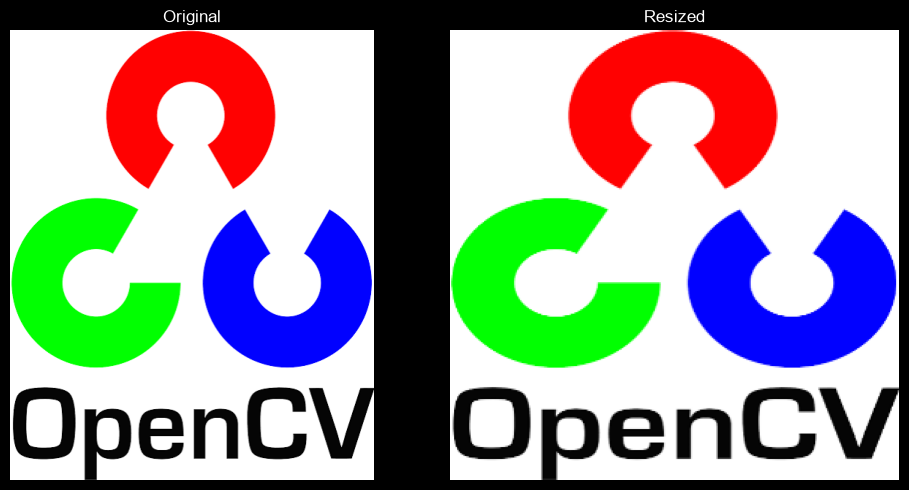

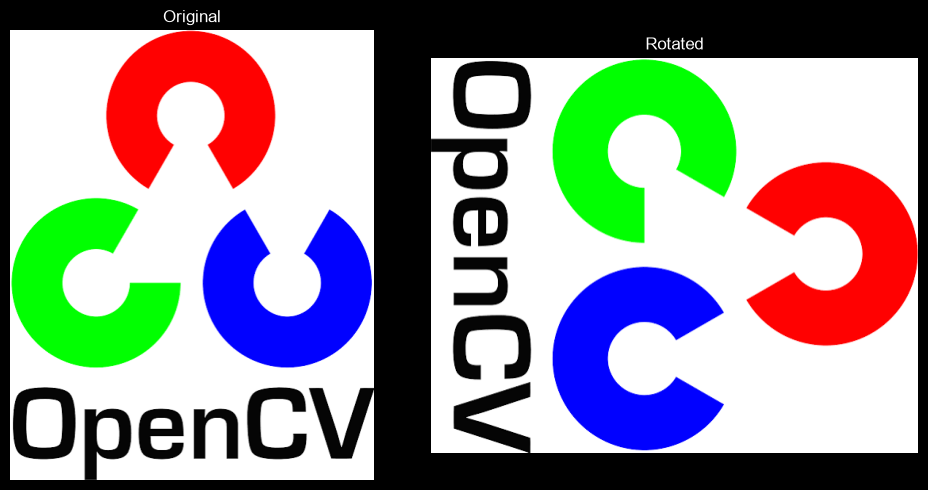

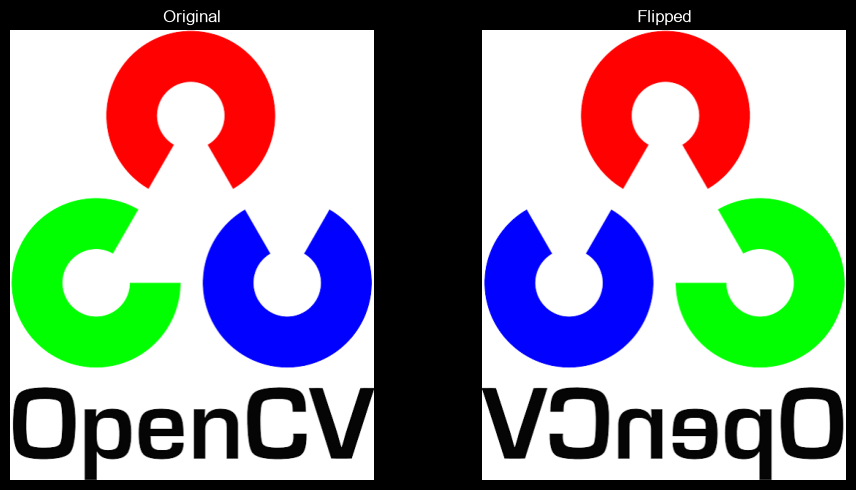

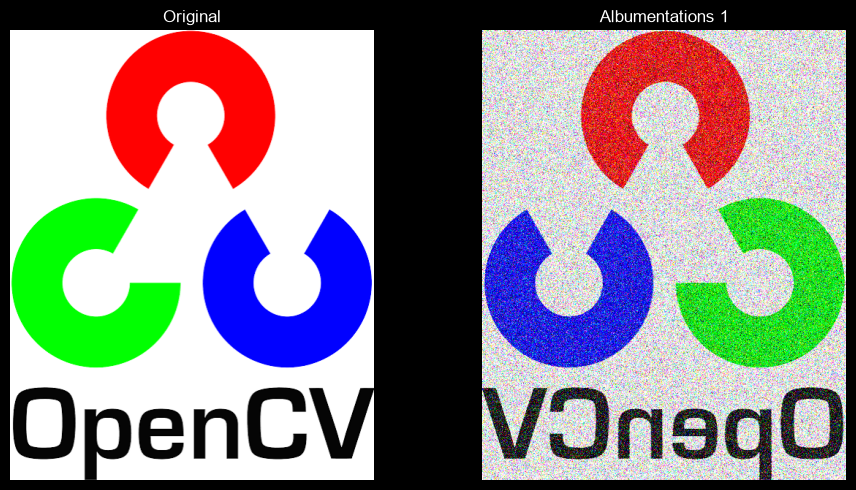

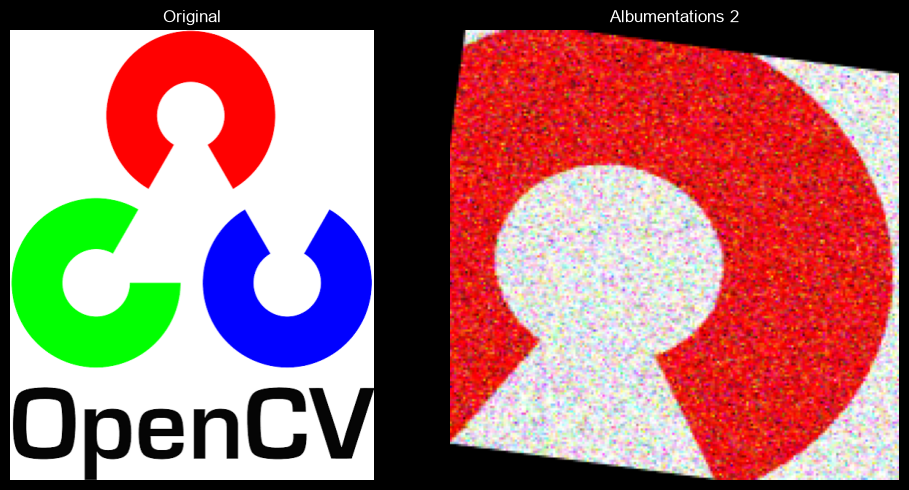

In [69]:
image_path = 'openCVImage.png'
image = load_image(image_path)

resized = cv2.resize(image, (300, 300))
display_images(image, resized, 'Resized')

rotated = cv2.rotate(image, cv2.ROTATE_90_CLOCKWISE)
display_images(image, rotated, 'Rotated')

flipped = cv2.flip(image, 1)
display_images(image, flipped, 'Flipped')

augmented_1 = augment_image(image, transform_pipeline)
display_images(image, augmented_1, 'Albumentations 1')

augmented_2 = augment_image(image, transform_pipeline)
display_images(image, augmented_2, 'Albumentations 2')